In [26]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import jieba
import re
import nltk
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz
import string

Movie Title Dictionary

In [27]:
# format: key is (english title, chinese douban title), 
# [english actor, chinese actor], 
# [top three actors, chinese translation of name], 
movies = {
    ('12 Angry Men','十二怒汉'): [
        ['Sidney Lumet', '西德尼·吕美特'],
        ['Henry Fonda', '亨利·方达', 'Lee J. Cobb', '李·J·科布', 'Ed Begley', '埃德·贝格利']
    ],
    ('2001: A Space Odyssey','2001太空漫游'): [
        ['Stanley Kubrick', '斯坦利·库布里克'],
        ['Keir Dullea', '基尔·杜利', 'Gary Lockwood', '加里·洛克伍德', 'William Sylvester', '威廉·西尔维斯特']
    ],
    ('A Beautiful Mind','美丽心灵'): [
        ['Ron Howard', '朗·霍华德'],
        ['Russell Crowe', '罗素·克劳', 'Jennifer Connelly', '詹妮弗·康纳利', 'Ed Harris', '艾德·哈里斯']
    ],
    ('Avatar','阿凡达'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Sam Worthington', '萨姆·沃辛顿', 'Zoe Saldana', '佐伊·索尔达娜', 'Sigourney Weaver', '西格妮·韦弗']
    ],
    ('Black Swan','黑天鹅'): [
        ['Darren Aronofsky', '达伦·阿罗诺夫斯基'],
        ['Natalie Portman', '娜塔莉·波特曼', 'Mila Kunis', '米拉·库尼斯', 'Vincent Cassel', '文森特·卡索']
    ],
    ('Bohemian Rhapsody','波西米亚狂想曲'): [
        ['Bryan Singer', '布莱恩·辛格'],
        ['Rami Malek', '拉米·马雷克', 'Lucy Boynton', '露西·宝通', 'Gwilym Lee', '格威利姆·李']
    ],
    ('Catch Me If You Can','猫鼠游戏'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Tom Hanks', '汤姆·汉克斯', 'Christopher Walken', '克里斯托弗·沃肯']
    ],
    ('Coco','寻梦环游记'): [
        ['Lee Unkrich', '李·昂克里奇', 'Adrian Molina', '阿德里安·莫利纳'],
        ['Anthony Gonzalez', '安东尼·冈萨雷斯', 'Gael García Bernal', '盖尔·加西亚·贝纳尔', 'Benjamin Bratt', '本杰明·布拉特']
    ],
    ('Django Unchained','被解救的姜戈'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['Jamie Foxx', '杰米·福克斯', 'Christoph Waltz', '克里斯托弗·瓦尔兹', 'Leonardo DiCaprio', '莱昂纳多·迪卡普里奥'],
    ],
    ('Fight Club','搏击俱乐部'): [
        ['David Fincher', '大卫·芬奇'],
        ['Brad Pitt', '布拉德·皮特', 'Edward Norton', '爱德华·诺顿', 'Helena Bonham Carter', '海伦娜·伯翰·卡特'],
    ],
    ('Forrest Gump','阿甘正传'): [
        ['Robert Zemeckis', '罗伯特·泽米吉斯'],
        ['Tom Hanks', '汤姆·汉克斯', 'Robin Wright', '罗宾·怀特', 'Gary Sinise', '加里·西尼斯']
    ],
    ('Frozen','冰雪奇缘'): [
        ['Chris Buck', '克里斯·巴克', 'Jennifer Lee', '詹妮弗·李'],
        ['Kristen Bell', '克里斯汀·贝尔', 'Idina Menzel', '伊迪娜·门泽尔', 'Jonathan Groff', '乔纳森·格罗夫']
    ],
    ('Gone Girl','消失的爱人'): [
        ['David Fincher', '大卫·芬奇'],
        ['Ben Affleck', '本·阿弗莱克', 'Rosamund Pike', '罗莎曼德·派克', 'Neil Patrick Harris', '尼尔·帕特里克·哈里斯']
    ],
    ('Good Will Hunting','心灵捕手'): [
        ['Gus Van Sant', '格斯·范·桑特'],
        ['Matt Damon', '马特·达蒙', 'Robin Williams', '罗宾·威廉姆斯', 'Ben Affleck', '本·阿弗莱克']
    ],
    ('Green Book','绿皮书'): [
        ['Peter Farrelly', '彼得·法雷里'],
        ['Viggo Mortensen', '维果·莫腾森', 'Mahershala Ali', '马赫沙拉·阿里', 'Linda Cardellini', '琳达·卡德里尼']
    ],
    ('Hacksaw Ridge','血战钢锯岭'): [
        ['Mel Gibson', '梅尔·吉布森'],
        ['Andrew Garfield', '安德鲁·加菲尔德', 'Sam Worthington', '萨姆·沃辛顿', 'Luke Bracey', '卢克·布雷西']
    ],
    ("Harry Potter and the Sorcerer's Stone",'哈利·波特与魔法石'): [
        ['Chris Columbus', '克里斯·哥伦布'],
        ['Daniel Radcliffe', '丹尼尔·雷德克里夫', 'Rupert Grint', '鲁伯特·格林特', 'Emma Watson', '艾玛·沃森']
    ],
    ('How to Train Your Dragon','驯龙高手'): [
        ['Dean DeBlois', '迪恩·德布洛斯', 'Chris Sanders', '克里斯·桑德斯'],
        ['Jay Baruchel', '杰伊·巴鲁切尔', 'Gerard Butler', '杰拉德·巴特勒', 'Craig Ferguson', '克雷格·费格森']
    ],
    ('Inception','盗梦空间'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Marion Cotillard', '玛丽昂·歌迪亚', 'Tom Hardy', '汤姆·哈迪']
    ],
    ('Inglourious Basterds','无耻混蛋'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['Brad Pitt', '布拉德·皮特', 'Christoph Waltz', '克里斯托弗·瓦尔兹', 'Mélanie Laurent', '梅拉尼·罗兰']
    ],
    ('Inside Out','头脑特工队'): [
        ['Pete Docter', '彼特·道格特', 'Ronnie Del Carmen', '罗纳尔多·德尔·卡门'],
        ['Amy Poehler', '艾米·波勒', 'Phyllis Smith', '菲莉丝·史密斯', 'Richard Kind', '理查德·坎德']
    ],
    ('Interstellar','星际穿越'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Matthew McConaughey', '马修·麦康纳', 'Anne Hathaway', '安妮·海瑟薇', 'Jessica Chastain', '杰西卡·查斯坦']
    ],
    ('Joker','小丑'): [
        ['Todd Phillips', '托德·菲利普斯'],
        ['Joaquin Phoenix', '华金·菲尼克斯', 'Robert De Niro', '罗伯特·德尼罗', 'Zazie Beetz', '扎兹·比茨']
    ],
    
    ('La La Land','爱乐之城'): [
        ['Damien Chazelle', '达米恩·查泽雷'],
        ['Ryan Gosling', '瑞恩·高斯林', 'Emma Stone', '艾玛·斯通', 'John Legend', '约翰·传奇']
    ],
    ('Life Is Beautiful','美丽人生'): [
        ['Roberto Benigni', '罗伯托·贝尼尼'],
        ['Roberto Benigni', '罗伯托·贝尼尼', 'Nicoletta Braschi', '尼可莱塔·布拉斯基', 'Giorgio Cantarini', '乔治·坎塔里尼']
    ],
    ('Life of Pi','少年派的奇幻漂流'): [
        ['Ang Lee', '李安'],
        ['Suraj Sharma', '苏拉·沙玛', 'Irrfan Khan', '伊尔凡·可汗', 'Rafe Spall', '拉菲·斯波']
    ],
    ('Lock, Stock and Two Smoking Barrels','两杆大烟枪'): [
        ['Guy Ritchie', '盖·里奇'],
        ['Jason Flemyng', '杰森·弗莱明', 'Dexter Fletcher', '德克斯特·弗莱彻', 'Nick Moran', '尼克·莫兰']
    ],
    ('Léon: The Professional','这个杀手不太冷'): [
        ['Luc Besson', '吕克·贝松'],
        ['Jean Reno', '让·雷诺', 'Natalie Portman', '娜塔莉·波特曼', 'Gary Oldman', '加里·奥德曼']
    ],
    ('Mad Max: Fury Road','疯狂的麦克斯4：狂暴之路'): [
        ['George Miller', '乔治·米勒'],
        ['Tom Hardy', '汤姆·哈迪', 'Charlize Theron', '查理兹·塞隆', 'Nicholas Hoult', '尼古拉斯·霍尔特']
    ],
    ('Memento','记忆碎片'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Guy Pearce', '盖·皮尔斯', 'Carrie-Anne Moss', '凯瑞-安·莫斯', 'Joe Pantoliano', '乔·潘托里亚诺']
    ],
    ('Monsters, Inc.','怪兽电力公司'): [
        ['Pete Docter', '彼特·道格特', 'David Silverman', '大卫·斯沃曼', 'Lee Unkrich', '李·昂克里奇'],
        ['John Goodman', '约翰·古德曼', 'Billy Crystal', '比利·克里斯托', 'Mary Gibbs', '玛丽·吉布斯']
    ],
    ("One Flew Over the Cuckoo's Nest",'飞越疯人院' ): [
        ['Miloš Forman', '米洛斯·福尔曼'],
        ['Jack Nicholson', '杰克·尼科尔森', 'Louise Fletcher', '路易丝·弗莱彻', 'Danny DeVito', '丹尼·德维托'] 
    ],
    ('Parasite','寄生虫'): [
        ['Bong Joon-ho', '奉俊昊'],
        ['Song Kang-ho', '宋康昊', 'Lee Sun-kyun', '李善均', 'Cho Yeo-jeong', '曹汝贞']
    ],
    ('Pirates of the Caribbean: The Curse of the Black Pearl','加勒比海盗'): [
        ['Gore Verbinski', '戈尔·维宾斯基'],
        ['Johnny Depp', '约翰尼·德普', 'Geoffrey Rush', '杰弗里·拉什', 'Orlando Bloom', '奥兰多·布鲁姆']
    ],
    ('Psycho','惊魂记'): [
        ['Alfred Hitchcock', '阿尔弗雷德·希区柯克'],
        ['Anthony Perkins', '安东尼·博金斯', 'Janet Leigh', '珍妮特·利', 'Vera Miles', '维拉·迈尔斯']
    ],
    ('Pulp Fiction','低俗小说'): [
        ['Quentin Tarantino', '昆汀·塔伦蒂诺'],
        ['John Travolta', '约翰·特拉沃尔塔', 'Samuel L. Jackson', '塞缪尔·杰克逊', 'Uma Thurman', '乌玛·瑟曼']
    ],
    ('Saving Private Ryan','拯救大兵瑞恩'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Tom Hanks', '汤姆·汉克斯', 'Matt Damon', '马特·达蒙', 'Tom Sizemore', '汤姆·塞兹摩尔']
    ],
    ("Schindler's List",'辛德勒的名单'): [
        ['Steven Spielberg', '史蒂文·斯皮尔伯格'],
        ['Liam Neeson', '连姆·尼森', 'Ben Kingsley', '本·金斯利', 'Ralph Fiennes', '拉尔夫·费因斯']
    ],
    ('Se7en','七宗罪'): [
        ['David Fincher', '大卫·芬奇'],
        ['Morgan Freeman', '摩根·弗里曼', 'Brad Pitt', '布拉德·皮特', 'Gwyneth Paltrow', '格温妮斯·帕特洛']
    ],
    ('Shutter Island','禁闭岛'): [
        ['Martin Scorsese', '马丁·斯科塞斯'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Mark Ruffalo', '马克·鲁法洛', 'Ben Kingsley', '本·金斯利']
    ],
    ('Slumdog Millionaire','贫民窟的百万富翁'): [
        ['Danny Boyle', '丹尼·博伊尔', 'Loveleen Tandan', '洛芙琳·坦丹'],
        ['Dev Patel', '戴夫·帕特尔', 'Freida Pinto', '芙蕾达·平托', 'Madhur Mittal', '麦活·米泰尔']
    ],
    ('Spider-Man: Into the Spider-Verse','蜘蛛侠：平行宇宙'): [
        ['Bob Persichetti', '鲍勃·佩尔西凯蒂', 'Peter Ramsey', '彼得·拉姆齐', 'Rodney Rothman', '罗德尼·罗斯曼'],
        ['Shameik Moore', '沙梅克·摩尔', 'Jake Johnson', '杰克·约翰逊', 'Hailee Steinfeld', '海莉·斯坦菲尔德']
    ],
    ('Spirited Away','千与千寻'): [
        ['Hayao Miyazaki', '宫崎骏'],
        ['Rumi Hiiragi', '柊瑠美', 'Miyu Irino', '入野自由', 'Mari Natsuki', '夏木真理']
    ],
    ('Terminator 2: Judgment Day','终结者2：审判日'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Arnold Schwarzenegger', '阿诺·施瓦辛格', 'Linda Hamilton', '琳达·汉密尔顿', 'Edward Furlong', '爱德华·福隆']
    ],
    ('The Bourne Ultimatum','谍影重重3'): [
        ['Paul Greengrass', '保罗·格林格拉斯'],
        ['Matt Damon', '马特·达蒙', 'Julia Stiles', '朱莉娅·斯蒂尔斯', 'David Strathairn', '大卫·斯特雷泽恩']
    ],
    ('The Curious Case of Benjamin Button','本杰明·巴顿奇事'): [
        ['David Fincher', '大卫·芬奇'],
        ['Brad Pitt', '布拉德·皮特', 'Cate Blanchett', '凯特·布兰切特', 'Taraji P. Henson', '塔拉吉·P·汉森']
    ],
    ('The Dark Knight','蝙蝠侠：黑暗骑士'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Christian Bale', '克里斯蒂安·贝尔', 'Heath Ledger', '希斯·莱杰', 'Aaron Eckhart', '艾伦·艾克哈特']
    ],
    ('The Godfather','教父'): [
        ['Francis Ford Coppola', '弗朗西斯·福特·科波拉'],
        ['Marlon Brando', '马龙·白兰度', 'Al Pacino', '阿尔·帕西诺', 'James Caan', '詹姆斯·肯恩']
    ],
    ('The Grand Budapest Hotel','布达佩斯大饭店'): [
        ['Wes Anderson', '韦斯·安德森'],
        ['Ralph Fiennes', '拉尔夫·费因斯', 'F. Murray Abraham', 'F·默里·亚伯拉罕', 'Mathieu Amalric', '马修·阿马立克']
    ],
    ('The Green Mile','绿里奇迹'): [
        ['Frank Darabont', '弗兰克·德拉邦特'],
        ['Tom Hanks', '汤姆·汉克斯', 'Michael Clarke Duncan', '迈克尔·克拉克·邓肯', 'David Morse', '大卫·摩斯']
    ],
    ('The Imitation Game','模仿游戏'): [
        ['Morten Tyldum', '莫滕·泰杜姆'],
        ['Benedict Cumberbatch', '本尼迪克特·康伯巴奇', 'Keira Knightley', '凯拉·奈特莉', 'Matthew Goode', '马修·古迪']
    ],
    ('The Intouchables','触不可及'): [
        ['Olivier Nakache', '奥利维埃·纳卡什', 'Éric Toledano', '埃里克·托莱达诺'],
        ['François Cluzet', '弗朗索瓦·克鲁塞', 'Omar Sy', '奥玛·希', 'Anne Le Ny', '安妮·勒尼']
    ],
    ('The Lion King','狮子王'): [
        ['Roger Allers', '罗杰·艾勒斯', 'Rob Minkoff', '罗伯·明可夫'],
        ['Matthew Broderick', '马修·布罗德里克', 'Jeremy Irons', '杰瑞米·艾恩斯', 'James Earl Jones', '詹姆斯·厄尔·琼斯']
    ],
    ('The Lord of the Rings: The Return of the King','指环王3：王者无敌'): [
        ['Peter Jackson', '彼得·杰克逊'],
        ['Elijah Wood', '伊利亚·伍德', 'Ian McKellen', '伊恩·麦克莱恩', 'Viggo Mortensen', '维果·莫腾森']
    ],
    ('The Martian','火星救援'): [
        ['Ridley Scott', '雷德利·斯科特'],
        ['Matt Damon', '马特·达蒙', 'Jessica Chastain', '杰西卡·查斯坦', 'Kristen Wiig', '克里斯汀·韦格']
    ],
    ('The Matrix','黑客帝国'): [
        ['Lana Wachowski', '拉娜·沃卓斯基', 'Lilly Wachowski', '莉莉·沃卓斯基'],
        ['Keanu Reeves', '基努·里维斯', 'Laurence Fishburne', '劳伦斯·菲什伯恩', 'Carrie-Anne Moss', '凯瑞-安·莫斯']
    ],
    ('The Notebook','恋恋笔记本'): [
        ['Nick Cassavetes', '尼克·卡萨维茨'],
        ['Ryan Gosling', '瑞恩·高斯林', 'Rachel McAdams', '瑞秋·麦克亚当斯', 'James Garner', '詹姆斯·加纳']
    ],
    ('The Pianist','钢琴家'): [
        ['Roman Polanski', '罗曼·波兰斯基'],
        ['Adrien Brody', '艾德里安·布洛迪', 'Thomas Kretschmann', '托马斯·克莱舒曼', 'Frank Finlay', '弗兰克·芬莱']
    ],
    ('The Prestige','致命魔术'): [
        ['Christopher Nolan', '克里斯托弗·诺兰'],
        ['Hugh Jackman', '休·杰克曼', 'Christian Bale', '克里斯蒂安·贝尔', 'Michael Caine', '迈克尔·凯恩']
    ],
    ('The Shawshank Redemption','肖申克的救赎'): [
        ['Frank Darabont', '弗兰克·德拉邦特'],
        ['Tim Robbins', '蒂姆·罗宾斯', 'Morgan Freeman', '摩根·弗里曼', 'Bob Gunton', '鲍勃·冈顿']
    ],
    ('The Silence of the Lambs','沉默的羔羊'): [
        ['Jonathan Demme', '乔纳森·德米'],
        ['Jodie Foster', '朱迪·福斯特', 'Anthony Hopkins', '安东尼·霍普金斯', 'Scott Glenn', '斯科特·格伦']
    ],
    ('The Sixth Sense','第六感'): [
        ['M. Night Shyamalan', 'M·奈特·沙马兰'],
        ['Bruce Willis', '布鲁斯·威利斯', 'Haley Joel Osment', '海利·乔·奥斯蒙', 'Toni Collette', '托妮·科莱特']
    ],
    ('The Truman Show','楚门的世界'): [
        ['Peter Weir', '彼得·威尔'],
        ['Jim Carrey', '金·凯瑞', 'Laura Linney', '劳拉·琳妮', 'Noah Emmerich', '诺亚·艾默里奇']
    ],
    ('Titanic','泰坦尼克号'): [
        ['James Cameron', '詹姆斯·卡梅隆'],
        ['Leonardo DiCaprio', '莱昂纳多·迪卡普里奥', 'Kate Winslet', '凯特·温丝莱特', 'Billy Zane', '比利·赞恩']
    ],
    ('Toy Story 3','玩具总动员3'): [
        ['Lee Unkrich', '李·昂克里奇'],
        ['Tom Hanks', '汤姆·汉克斯', 'Tim Allen', '蒂姆·艾伦', 'Joan Cusack', '琼·库萨克']
    ],
    ('Up','飞屋环游记'): [
        ['Pete Docter', '彼特·道格特', 'Bob Peterson', '鲍勃·彼德森'],
        ['Ed Asner', '艾德·阿斯纳', 'Christopher Plummer', '克里斯托弗·普卢默', 'Jordan Nagai', '长井章太']
    ],
    ('WALL·E','机器人总动员'): [
        ['Andrew Stanton', '安德鲁·斯坦顿'],
        ['Ben Burtt', '本·伯特', 'Elissa Knight', '艾丽莎·奈特', 'Jeff Garlin', '杰夫·格尔林']
    ],
    ('Whiplash','爆裂鼓手'): [
        ['Damien Chazelle', '达米恩·查泽雷'],
        ['Miles Teller', '迈尔斯·特勒', 'J.K. Simmons', 'J·K·西蒙斯', 'Paul Reiser', '保罗·赖泽']
    ]
}

en_to_cn = {en: cn for (en, cn) in movies.keys()}

Load in CSV, eng_stopwords, ch_stopwords

In [28]:
# Load CSVs
df_cn = pd.read_csv('../douban_reviews.csv')

#eng_stopwords = set(stopwords.words('english'))
eng_stopwords = set(open('../text_processing/custom_english_stopwords.txt', encoding='utf-8').read().split())
cn_stopwords = set(open('../text_processing/chinese_stopwords.txt', encoding='utf-8').read().split())

Cap reviews per movie at 70 to equalize distribution

In [29]:
# Function to sample up to 70 reviews per movie
def sample_reviews(group):
    if len(group) > 70:
        return group.sample(n=70, random_state=None)
    else:
        return group

# Apply the sampling function to each movie group
df_cn_balanced = df_cn.groupby('title', group_keys=False).apply(sample_reviews)

# Reset index to clean it up
df_cn_balanced = df_cn_balanced.reset_index(drop=True)
df_cn = df_cn_balanced

/var/folders/m_/hhg0dx_j62qbf4m6rdt4_3qc0000gn/T/ipykernel_40177/511339441.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cn_balanced = df_cn.groupby('title', group_keys=False).apply(sample_reviews)


Avatar 70
Parasite 70
Life of Pi 70
La La Land 70
Joker 70
Interstellar 70
Hacksaw Ridge 70
The Dark Knight 68
Inception 65
Titanic 65
Green Book 64
2001: A Space Odyssey 62
Se7en 58
Whiplash 56
Slumdog Millionaire 55
Coco 54
The Notebook 54
Forrest Gump 51
Black Swan 51
The Shawshank Redemption 50
Fight Club 45
Gone Girl 44
The Prestige 41
Léon: The Professional 40
One Flew Over the Cuckoo's Nest 38
Inglourious Basterds 34
Life Is Beautiful 34
The Curious Case of Benjamin Button 33
The Martian 32
Django Unchained 32
Schindler's List 31
Pulp Fiction 29
Shutter Island 27
Bohemian Rhapsody 26
Spider-Man: Into the Spider-Verse 24
The Godfather 24
The Truman Show 24
The Imitation Game 23
Frozen 22
Up 21
Spirited Away 21
The Silence of the Lambs 19
Mad Max: Fury Road 19
A Beautiful Mind 17
The Green Mile 16
Memento 16
Good Will Hunting 15
WALL·E 15
The Intouchables 14
The Matrix 12
Saving Private Ryan 11
Inside Out 10
The Lord of the Rings: The Return of the King 9
Psycho 9
Lock, Stock and 

<Axes: xlabel='title'>

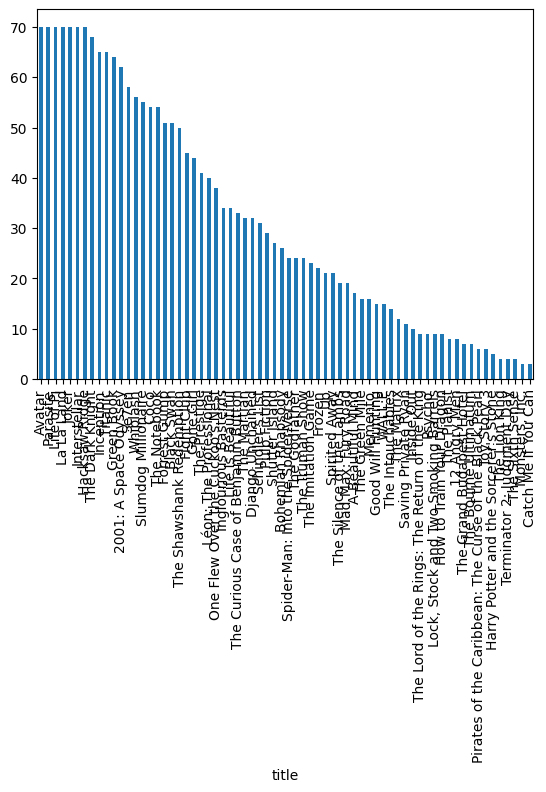

In [30]:
#view title distribution
for title in df_cn['title'].value_counts().index:
    print(title, df_cn['title'].value_counts()[title])

df_cn['title'].value_counts().plot(kind='bar')

Remove URLS from reviews

In [31]:
# Regex pattern to match URLs starting with 'http' and stopping at the first Chinese character
url_pattern = re.compile(r'http[^\u4e00-\u9fff\s]*')

def remove_urls(text):
    # Replace each URL match with a space
    return url_pattern.sub(' ', text)

# Apply to the DataFrame column
df_cn['review_text'] = df_cn['review_text'].apply(remove_urls)

Tokenize self mentions of titles, actors, directors

In [32]:
# tokenize self mentions of titles, actors, and director
SPECIAL_TOKENS = {"<MOVIE_TITLE>", "<DIRECTOR_NAME>", "<ACTOR_NAME>"}
def normalize_bilingual(text):
    """Normalize Chinese-English text for matching:
    - Lowercases English letters
    - Removes all punctuation/symbols (both Chinese and Western)
    - Preserves Chinese characters, numbers, and whitespace
    """
    return re.sub(
        r"[^\w\s]",          # Match non-word/non-whitespace characters
        "", 
        text.lower(),        # Lowercase only affects English
        flags=re.UNICODE     # Ensure proper handling of Chinese characters
    )

def find_bilingual_title_mentions(text, title_tuple):
    """
    Find exact matches for Chinese titles in 《》 and English titles.
    """
    matches = []
    english_title, chinese_title = title_tuple

    # English title matching (case-insensitive, whole-word)
    if english_title and len(english_title) >= 2:
        en_pattern = r'\b' + re.escape(english_title) + r'\b'
        for match in re.finditer(en_pattern, text, flags=re.IGNORECASE):
            matches.append((match.start(), match.end(), "<MOVIE_TITLE>"))

    # Chinese title matching (exact substring or 《title》)
    if chinese_title and len(chinese_title) >= 2:
        # Match both bare title and 《title》
        patterns = [
            re.escape(chinese_title),          # Bare title: 阿甘正传
            re.escape(f"《{chinese_title}》")  # Bracketed: 《阿甘正传》
        ]
        
        for pattern in patterns:
            for match in re.finditer(pattern, text):
                matches.append((match.start(), match.end(), "<MOVIE_TITLE>"))

    return matches

def is_overlap(span, existing_spans):
    new_start, new_end = span
    for (exist_start, exist_end) in existing_spans:
        if (new_start < exist_end) and (new_end > exist_start):
            return True
    return False

def is_likely_general_name_reference(text, start, end):
    context_start = max(0, start - 40)
    context_end = min(len(text), end + 40)
    context = text[context_start:context_end].lower()

    positive_indicators = [
        'director', 'directed by', '主演', '主演者', '饰演', '表演', '扮演', '演员', '配音', '角色', '由', '参演', '出演',
        'star', 'performance', 'played by', 'cast', 'role', 'film', 'movie', 'drama', 'show', 'episode',
        'recommend', 'amazing', 'great', 'awesome', 'love', 'favorite', 'best', 'classic', 'iconic', 'legendary',
        'yyds', '安利', '吹爆', '神仙', '教科书级', '彩蛋', '二刷', '哭死', '破防', '小姐姐', '小哥哥'
    ]

    # Generalized negative indicators (common function words, negations, and question words)
    negative_indicators = [
        'the', 'a', 'an', 'is', 'was', 'were', 'are', 'his', 'her', 'its', 'their', 'this', 'that',
        '了', '的', '在', '和', '这', '那', '他', '她', '它', '怎样', '怎么', '为什么', '居然', '真的', '不要', '吗', '吧', '啊',
        '！', '？', '～', '不是', '没', '没有', '别', '无', '非'
    ]

        # Check positive indicators
    if any(indicator in context for indicator in positive_indicators):
        return True

        # Check negative indicators before the match
    word_before = text[max(0, start-10):start].strip().split()
    if word_before and word_before[-1].lower() in negative_indicators:
        return False

    return True

def find_bilingual_name_mentions(text, names_list):
    """
    Enhanced bilingual name matcher that:
    - Matches full names directly
    - Matches first/last names with context validation
    - Handles possessive forms and Chinese names
    """
    matches = []
    seen_spans = set()
    # Sort by English name length first, then Chinese
    sorted_names = sorted(
        names_list,
        key=lambda x: (-len(x[0]), -len(x[1])) if x[0] else (-len(x[1]),)
    )
    
    for en_name, zh_name, tag in sorted_names:
        # --- English Name Matching ---
        if en_name:
            name_parts = en_name.split()
            
            # 1. Full name match (no context check needed)
            full_pattern = re.compile(rf'\b{re.escape(en_name)}\b', re.IGNORECASE)
            for m in full_pattern.finditer(text):
                span = (m.start(), m.end())
                if not is_overlap(span, seen_spans):
                    matches.append((*span, tag))
                    seen_spans.add(span)
            
            # 2. First and last name components with context check
            if len(name_parts) >= 2:
                first_part = name_parts[0]
                last_part = name_parts[-1]

                # Match first name (e.g. "Tom" from "Tom Hanks")
                first_pattern = re.compile(rf'\b{re.escape(first_part)}\b', re.IGNORECASE)
                for m in first_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)
                
                # Match last name (e.g. "Hanks" from "Tom Hanks")
                last_pattern = re.compile(rf'\b{re.escape(last_part)}\b', re.IGNORECASE)
                for m in last_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)
            
            # 3. Possessive forms (e.g. "Hanks'")
            if len(name_parts) >= 1:
                last_part = name_parts[-1]
                possessive_pattern = re.compile(rf'\b{re.escape(last_part)}\'s?\b', re.IGNORECASE)
                for m in possessive_pattern.finditer(text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)

        # --- Chinese Name Matching ---
        if zh_name and len(zh_name) >= 2:
            # Full name match
            idx = text.find(zh_name)
            while idx != -1:
                span = (idx, idx + len(zh_name))
                if not is_overlap(span, seen_spans):
                    matches.append((*span, tag))
                    seen_spans.add(span)
                idx = text.find(zh_name, idx + 1)
            
            # Component matches (e.g. 迪卡普里奥 from 莱昂纳多·迪卡普里奥)
            components = zh_name.split('·')
            for component in components:
                for m in re.finditer(re.escape(component), text):
                    span = (m.start(), m.end())
                    if not is_overlap(span, seen_spans):
                        if is_likely_general_name_reference(text, span[0], span[1]):
                            matches.append((*span, tag))
                            seen_spans.add(span)

    return matches

def is_common_word_with_s(word):
    """Check if a word is a common English word that might end with 's."""
    common_words = {
        'his', 'hers', 'its', 'theirs', 'ours', 'yours', 'this', 'that',
        'was', 'has', 'does', 'goes', 'comes', 'makes', 'takes', 'gives',
        'seems', 'looks', 'feels', 'sounds', 'appears', 'becomes'
    }
    return word.lower() in common_words

def get_common_words():
    """Get a set of common English words to avoid matching."""
    return {
        'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'it',
        'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at', 'this',
        'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her', 'she', 'or',
        'an', 'will', 'my', 'one', 'all', 'would', 'there', 'their', 'what',
        'so', 'up', 'out', 'if', 'about', 'who', 'get', 'which', 'go', 'me',
        'when', 'make', 'can', 'like', 'time', 'no', 'just', 'him', 'know',
        'take', 'people', 'into', 'year', 'your', 'good', 'some', 'could',
        'them', 'see', 'other', 'than', 'then', 'now', 'look', 'only', 'come',
        'its', 'over', 'think', 'also', 'back', 'after', 'use', 'two', 'how',
        'our', 'work', 'first', 'well', 'way', 'even', 'new', 'want', 'because',
        'any', 'these', 'give', 'day', 'most', 'us', 'still', 'find', 'tell',
        'really', 'dark', 'great', 'movie', 'film', 'scene', 'character', 'story',
        'plot', 'director', 'actor', 'actress', 'hero', 'villain', 'killer',
        'murder', 'death', 'child', 'mind', 'moral', 'figure', 'foundation'
    }

 # 2. Prepare director/actor entries
def prepare_entities(raw_list, tag):
    """Convert [en1, zh1, en2, zh2...] to [(en1, zh1, tag), (en2, zh2, tag)...]"""
    entities = []
    for i in range(0, len(raw_list), 2):
        en = raw_list[i] if i < len(raw_list) else ""
        zh = raw_list[i+1] if (i+1) < len(raw_list) else ""
        entities.append((en, zh, tag))
    return entities

def preprocess_movie_review(text, movies, title_tuple):
    """
    Bilingual movie review preprocessor that handles both Chinese and English text.
    - movies: Dictionary where keys are (english_title, chinese_title) tuples
    - values: [directors, actors] where:
      directors = [en_name1, zh_name1, en_name2, zh_name2...]
      actors = [en_name1, zh_name1, en_name2, zh_name2...]
    """
    # Basic preprocessing if movie not in dictionary
    if title_tuple not in movies:
        text_normalized = normalize_bilingual(text)
        words = text_normalized.split()
        stops = eng_stopwords
        cleaned = [w for w in words if w not in eng_stopwords and w not in cn_stopwords]
        return " ".join(cleaned)

    directors, actors = movies[title_tuple]

    # Find all entity matches
    entity_matches = []
    
    # 1. Find movie title mentions (both English and Chinese)
    entity_matches.extend(find_bilingual_title_mentions(text, title_tuple))
    
    # 3. Find director and actor mentions
    director_entries = prepare_entities(directors, "<DIRECTOR_NAME>")
    actor_entries = prepare_entities(actors, "<ACTOR_NAME>")
    
    entity_matches.extend(find_bilingual_name_mentions(text, director_entries))
    entity_matches.extend(find_bilingual_name_mentions(text, actor_entries))

    # 4. Remove overlapping matches (prioritize longer spans)
    entity_matches.sort(key=lambda x: (x[0], -x[1]))  # Sort by start pos then negative length
    filtered_matches = []
    prev_end = -1
    for start, end, tag in entity_matches:
        if start >= prev_end:
            filtered_matches.append((start, end, tag))
            prev_end = end

    # 5. Replace entities in text (reverse order to preserve indices)
    text_processed = text
    for start, end, tag in reversed(filtered_matches):
        text_processed = text_processed[:start] + tag + text_processed[end:]

    # 6. Clean text while preserving special tokens
    text_processed = text_processed.lower()
    
    # Preserve special tokens during punctuation removal
    for token in SPECIAL_TOKENS:
        text_processed = text_processed.replace(token.lower(), f" {token} ")
    
    # Remove non-special punctuation
    text_processed = re.sub(r"[^\w\s<>]", " ", text_processed)
    
    words = text_processed.split()
    # Updated stopword check for both languages
    cleaned = [w for w in words if (w in SPECIAL_TOKENS) or (w not in eng_stopwords and w not in cn_stopwords)]
    
    return " ".join(cleaned)

In [33]:
df_cn['processed_comment'] = df_cn.apply(
    lambda row: preprocess_movie_review(
        row['review_text'], 
        movies, 
        (row['title'], en_to_cn.get(row['title'], None))  # Pass the tuple
    ),
    axis=1
)

Remove new line char and custom stopwords

In [34]:
def clean_chinese(text):
    # Remove newline and carriage return characters
    text = text.replace('\n', '').replace('\r', '')

    # Lowercase English letters only
    text = re.sub(r'[A-Za-z]+', lambda m: m.group(0).lower(), text)

    # Tokenize using jieba
    words = jieba.lcut(text)

    # Remove stopwords
    words = [word for word in words if word not in cn_stopwords]

    return ' '.join(words)

df_cn['more_processed_comment'] = df_cn['processed_comment'].apply(clean_chinese)

In [35]:
#load in custom stopwords
custom_stopwords = set(open('../text_processing/custom_chinese_stopwords.txt', encoding='utf-8').read().split())
words = []
for word in custom_stopwords:
    word = word.lower()
    words.append(word)
custom_stopwords = set(words)

In [36]:
def clean_more(text):
    # Remove newline and carriage return characters
    text = text.replace('< movie _ title >', '<movie_title>').replace('< actor _ name >', '<actor_name>').replace('< director _ name >', '<director_name>')

    words = [w for w in text.split() if w not in custom_stopwords]

    return ' '.join(words)

df_cn['clean_comment'] = df_cn['more_processed_comment'].apply(clean_more)
comments = df_cn["clean_comment"].dropna().tolist()

Vector Embeddings

In [37]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "jinaai/jina-embeddings-v2-base-zh"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Some weights of BertModel were not initialized from the model checkpoint at jinaai/jina-embeddings-v2-base-zh and are newly initialized: ['encoder.layer.5.output.LayerNorm.weight', 'encoder.layer.4.output.LayerNorm.weight', 'encoder.layer.9.intermediate.dense.weight', 'encoder.layer.8.intermediate.dense.weight', 'encoder.layer.6.output.LayerNorm.weight', 'encoder.layer.2.output.dense.weight', 'encoder.layer.7.output.LayerNorm.weight', 'encoder.layer.4.output.dense.weight', 'encoder.layer.9.output.dense.bias', 'encoder.layer.2.intermediate.dense.weight', 'encoder.layer.8.output.LayerNorm.bias', 'encoder.layer.0.output.LayerNorm.weight', 'encoder.layer.1.intermediate.dense.weight', 'embeddings.position_embeddings.weight', 'encoder.layer.2.intermediate.dense.bias', 'encoder.layer.7.intermediate.dense.weight', 'encoder.layer.6.intermediate.dense.weight', 'encoder.layer.0.output.LayerNorm.bias', 'encoder.layer.7.output.dense.bias', 'encoder.layer.4.output.dense.bias', 'encoder.layer.1.outpu

In [15]:
def embed_comments(texts):
    embeddings = []
    for text in texts:
        inputs = tokenizer([text], return_tensors="pt", truncation=True, padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1).numpy()
            embeddings.append(emb[0])
    return embeddings

embeddings = embed_comments(comments)

In [16]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(comments, show_progress_bar=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Batches: 100%|██████████| 68/68 [00:10<00:00,  6.73it/s]


Clustering

In [17]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6 # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_cn['cluster'] = labels

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [18]:
df_cn['cluster'].value_counts()

cluster
0    576
5    400
4    395
1    351
3    241
2    190
Name: count, dtype: int64

Keyword Extraction and Cluster Analysis

In [19]:
#analysis tools
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from keybert import KeyBERT
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def extract_keybert_keywords(df_en, model, num_keywords=10):
    print("=== KEYBERT KEYWORDS ===\n")
    kw_model = KeyBERT(model)
    for i in range(num_clusters):
        cluster_comments = df_en[df_en['cluster'] == i]['clean_comment'].tolist()
        joined = " ".join(cluster_comments)
        keywords = kw_model.extract_keywords(joined, top_n=num_keywords)
        print(f"Cluster {i} keywords:", keywords)

    print()

def analyze_clusters_comprehensive(df_en, text_column='processed_comment'):
    """
    Comprehensive cluster analysis with multiple methods
    """
    
    # 1. TF-IDF Based Analysis (most discriminative terms per cluster)
    print("=== TF-IDF DISCRIMINATIVE TERMS ===\n")
    
    # Create a document for each cluster by joining all comments
    cluster_docs = []
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist())
        cluster_docs.append(cluster_text)
    
    # Compute TF-IDF
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 3), stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()
    
    # Get top terms for each cluster based on TF-IDF scores
    for i in range(len(cluster_docs)):
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[-15:][::-1]  # Top 15 terms
        top_terms = [(feature_names[idx], scores[idx]) for idx in top_indices]
        
        print(f"Cluster {i} - Most Discriminative Terms:")
        for term, score in top_terms[:10]:
            print(f"  {term}: {score:.3f}")
        print()
    
    # 3. Movie and Rating Distribution
    print("\n=== MOVIE & RATING DISTRIBUTION ===\n")
    
    for i in range(df_en['cluster'].nunique()):
        cluster_df = df_en[df_en['cluster'] == i]
        
        print(f"Cluster {i}:")
        print(f"  Size: {len(cluster_df)} reviews")
        
        # Top movies in this cluster
        top_movies = cluster_df['title'].value_counts().head(5)
        print(f"  Top movies:")
        for movie, count in top_movies.items():
            print(f"    - {movie}: {count} reviews")
        
        # Rating distribution if available
        if 'rating' in df_en.columns:
            print(f"  Average rating: {cluster_df['rating'].mean():.2f}")
            print(f"  Rating std: {cluster_df['rating'].std():.2f}")
        
        print()

    # 5. Length Analysis
    print("\n=== REVIEW LENGTH ANALYSIS ===\n")
    
    df_en['review_length'] = df_en[text_column].str.split().str.len()
    
    for i in range(df_en['cluster'].nunique()):
        cluster_lengths = df_en[df_en['cluster'] == i]['review_length']
        print(f"Cluster {i}:")
        print(f"  Average length: {cluster_lengths.mean():.1f} words")
        print(f"  Median length: {cluster_lengths.median():.1f} words")
        print()
    
    # 4. Special Token Analysis
    print("\n=== SPECIAL TOKEN USAGE ===\n")
    
    special_tokens = [ 'director_name', 'actor_name']
    
    for i in range(df_en['cluster'].nunique()):
        cluster_comments = df_en[df_en['cluster'] == i][text_column].tolist()
        all_text = ' '.join(cluster_comments)
        
        print(f"Cluster {i}:")
        for token in special_tokens:
            count = all_text.count(token)
            avg_per_review = count / len(cluster_comments)
            print(f"  {token}: {count} total ({avg_per_review:.2f} per review)")
        print()

def get_sample_reviews(df_en, n_samples=3):
#print some random comments from each cluster
    """
    Get representative reviews from each cluster
    """
    print("\n=== RANDOM SAMPLE REVIEWS ===\n")
    
    for cluster_num in sorted(df_en['cluster'].unique()):
        print(f"\nCluster {cluster_num}:")
        sample_comments = df_en[df_en['cluster'] == cluster_num]['review_text'].sample(n_samples, random_state=42)
        for comment in sample_comments:
            print(" -", comment)
            print()
        print("-" * 40)

def extract_unique_ngrams(df_en, text_column='processed_comment'):
    """
    Find n-grams that are unique or highly specific to each cluster
    """
    print("\n=== UNIQUE N-GRAMS PER CLUSTER ===\n")
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    # Get n-grams for each cluster
    cluster_ngrams = {}
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = df_en[df_en['cluster'] == i][text_column].tolist()
        
        # Extract bigrams and trigrams
        vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=100)
        try:
            ngram_counts = vectorizer.fit_transform(cluster_text)
            feature_names = vectorizer.get_feature_names_out()
            
            # Sum occurrences across all documents in cluster
            total_counts = ngram_counts.sum(axis=0).A1
            ngram_freq = list(zip(feature_names, total_counts))
            ngram_freq.sort(key=lambda x: x[1], reverse=True)
            
            cluster_ngrams[i] = dict(ngram_freq[:20])  # Top 20 n-grams
        except:
            cluster_ngrams[i] = {}
    
    # Find n-grams unique to each cluster
    for i in range(df_en['cluster'].nunique()):
        print(f"Cluster {i} - Unique/Distinctive N-grams:")
        
        current_ngrams = set(cluster_ngrams[i].keys())
        other_ngrams = set()
        
        for j in range(df_en['cluster'].nunique()):
            if j != i:
                other_ngrams.update(cluster_ngrams[j].keys())
        
        unique_ngrams = current_ngrams - other_ngrams
        
        if unique_ngrams:
            for ngram in list(unique_ngrams)[:10]:
                print(f"  - {ngram}: {cluster_ngrams[i][ngram]} occurrences")
        else:
            # If no unique n-grams, show most frequent
            for ngram, count in list(cluster_ngrams[i].items())[:5]:
                print(f"  - {ngram}: {count} occurrences")
        print()

def visualize_clusters(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction
    """
    # PCA visualization
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                         c=df_en['cluster'], cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Clusters in PCA Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    # t-SNE visualization (for smaller datasets)
    if len(df_en) < 5000:  # t-SNE is computationally expensive
        tsne = TSNE(n_components=2, random_state=42)
        tsne_coords = tsne.fit_transform(embeddings)
        
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], 
                             c=df_en['cluster'], cmap='tab10', alpha=0.6)
        plt.colorbar(scatter)
        plt.title('Clusters in t-SNE Space')
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
    
    plt.tight_layout()
    plt.show()

def visualize_clusters2(df_en, embeddings):
    """
    Visualize clusters using dimensionality reduction but different output
    """
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    df_en['x'] = reduced[:, 0]
    df_en['y'] = reduced[:, 1]

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_en, x='x', y='y', hue='cluster', palette='tab10')
    plt.title("IMDB Comment Clusters")
    plt.show()

def analyze_cluster_themes(df_en, text_column='processed_comment'):
    """
    High-level theme analysis based on semantic patterns
    """
    print("\n=== POTENTIAL CLUSTER THEMES ===\n")
    
    # Define theme indicators
    theme_patterns = {
        'Technical/Cinematography': [
            # English terms
            'cinematography', 'camera', 'shot', 'visual', 'effects', 'lighting', 'score', 'soundtrack',
            'editing', 'montage', 'framing', 'composition', 'color grading', 'special effects', 'vfx',
            'sound design', 'audio', 'music', 'film grain', 'aspect ratio', 'lens', 'focus',
            'depth of field', 'bokeh', 'exposure', 'contrast', 'saturation',
            # Chinese terms
            '摄影', '镜头', '视觉', '特效', '灯光', '配乐', '音响', '剪辑', '蒙太奇',
            '构图', '调色', '音效设计', '音乐', '画面', '色彩', '光影', '景深', '对焦',
            '曝光', '对比度', '饱和度', '画质', '视效'
        ],
        
        'Plot/Story': [
            # English terms
            'plot', 'story', 'narrative', 'ending', 'twist', 'predictable', 'boring', 'confusing',
            'storyline', 'script', 'screenplay', 'dialogue', 'pacing', 'structure', 'climax',
            'resolution', 'character development', 'arc', 'subplot', 'foreshadowing', 'flashback',
            'theme', 'message', 'moral', 'symbolism', 'metaphor', 'allegory',
            # Chinese terms
            '剧情', '故事', '叙事', '结局', '转折', '反转', '可预测', '无聊', '混乱',
            '故事线', '剧本', '对话', '节奏', '结构', '高潮', '解决', '人物发展',
            '情节', '伏笔', '闪回', '主题', '寓意', '象征', '隐喻', '寓言'
        ],
        
        'Acting/Performance': [
            # English terms
            '<ACTOR_NAME>', 'actor_name', 'acting', 'performance', 'character', 'role', 'cast',
            '演员', 'protagonist', 'antagonist', 'supporting actor', 'lead role', 'ensemble',
            'chemistry', 'charisma', 'believable', 'convincing', 'overacting', 'underacting',
            'method acting', 'improvisation', 'delivery', 'emotion', 'expression',
            # Chinese terms
            '演员', '表演', '角色', '演技', '主角', '配角', '反派', '演出', '情感',
            '表情', '台词功底', '化学反应', '魅力', '可信度', '过度表演', '表演不足',
            '即兴发挥', '情绪', '演绎'
        ],
        
        'Direction': [
            # English terms
            '<DIRECTOR_NAME>', 'director_name', 'direction', 'directed', 'filmmaker',
            'directing', 'vision', 'style', 'auteur', 'mise-en-scène', 'directorial',
            'execution', 'craft', 'artistic vision', 'creative control', 'helm',
            # Chinese terms
            '导演', '执导', '导演风格', '艺术视野', '执行', '创作', '掌控', '导演手法',
            '艺术家', '创意', '视觉风格'
        ],
        
        'Genre-specific': [
            # English terms
            'horror', 'comedy', 'thriller', 'drama', 'action', 'romantic', 'sci-fi', 'fantasy',
            'western', 'noir', 'documentary', 'biography', 'historical', 'war', 'crime',
            'mystery', 'adventure', 'animation', 'musical', 'family', 'indie', 'arthouse',
            # Chinese terms
            '恐怖', '喜剧', '惊悚', '剧情', '动作', '浪漫', '爱情', '科幻', '奇幻',
            '西部', '黑色电影', '纪录片', '传记', '历史', '战争', '犯罪', '悬疑',
            '冒险', '动画', '音乐剧', '家庭', '独立电影', '艺术片'
        ],
        
        'Emotional Response': [
            # English terms
            'love', 'hate', 'disappoint', 'amazing', 'terrible', 'worst', 'best', 'masterpiece',
            'brilliant', 'awful', 'stunning', 'boring', 'exciting', 'thrilling', 'moving',
            'touching', 'hilarious', 'frightening', 'beautiful', 'ugly', 'perfect', 'flawed',
            'memorable', 'forgettable', 'impressive', 'disappointing', 'satisfying',
            # Chinese terms
            '喜爱', '讨厌', '失望', '惊艳', '糟糕', '最差', '最好', '杰作', '经典',
            '精彩', '可怕', '惊人', '无聊', '激动', '刺激', '感动', '触动', '搞笑',
            '恐怖', '美丽', '丑陋', '完美', '有缺陷', '难忘', '遗忘', '印象深刻',
            '令人失望', '满意', '震撼'
        ],
        
        'Critical/Analytical': [
            # English terms
            'overrated', 'underrated', 'critic', 'review', 'analysis', 'interpret',
            'evaluation', 'assessment', 'critique', 'rating', 'score', 'recommendation',
            'comparison', 'influence', 'impact', 'legacy', 'cultural significance',
            'artistic merit', 'commercial success', 'box office', 'awards', 'nominations',
            # Chinese terms
            '被高估', '被低估', '评论家', '评论', '分析', '解读', '评估', '评价',
            '批评', '评分', '推荐', '比较', '影响', '冲击', '遗产', '文化意义',
            '艺术价值', '商业成功', '票房', '奖项', '提名'
        ],
        
        'Political/Ideological Sentiment': [
            # English terms
            'propaganda', 'bias', 'political', 'ideology', 'conservative', 'liberal',
            'progressive', 'reactionary', 'nationalist', 'patriotic', 'anti-war', 'pro-war',
            'feminist', 'sexist', 'racist', 'diversity', 'representation', 'inclusive',
            'exclusive', 'mainstream', 'alternative', 'subversive', 'establishment',
            'counter-culture', 'social commentary', 'political correctness', 'woke',
            'traditional values', 'modern values', 'censorship', 'freedom of expression',
            # Chinese terms
            '宣传', '偏见', '政治', '意识形态', '保守', '自由主义', '进步', '反动',
            '民族主义', '爱国', '反战', '支持战争', '女权主义', '性别歧视', '种族主义',
            '多样性', '代表性', '包容', '排斥', '主流', '另类', '颠覆', '建制',
            '反文化', '社会评论', '政治正确', '传统价值', '现代价值', '审查', '表达自由'
        ],
        
        'Cultural/Social Commentary': [
            # English terms
            'cultural', 'society', 'social issues', 'class', 'inequality', 'poverty', 'wealth',
            'religion', 'spirituality', 'atheism', 'morality', 'ethics', 'justice',
            'oppression', 'liberation', 'identity', 'sexuality', 'gender', 'race',
            'ethnicity', 'immigration', 'globalization', 'capitalism', 'socialism',
            # Chinese terms
            '文化', '社会', '社会问题', '阶级', '不平等', '贫困', '财富', '宗教',
            '精神', '无神论', '道德', '伦理', '正义', '压迫', '解放', '身份',
            '性取向', '性别', '种族', '民族', '移民', '全球化', '资本主义', '社会主义'
        ],
        
        'Production/Industry': [
            # English terms
            'budget', 'production', 'studio', 'independent', 'hollywood', 'international',
            'blockbuster', 'franchise', 'sequel', 'prequel', 'remake', 'reboot',
            'adaptation', 'original', 'distribution', 'marketing', 'promotion',
            'release', 'premiere', 'festival', 'awards season', 'oscar bait',
            # Chinese terms
            '预算', '制作', '工作室', '独立', '好莱坞', '国际', '大片', '系列',
            '续集', '前传', '重拍', '重启', '改编', '原创', '发行', '营销',
            '宣传', '发布', '首映', '电影节', '颁奖季', '冲奥'
        ],
        
        'Audience/Reception': [
            # English terms
            'audience', 'viewers', 'fans', 'general public', 'target demographic',
            'accessibility', 'entertainment value', 'rewatchability', 'cult following',
            'mainstream appeal', 'niche', 'polarizing', 'consensus', 'word of mouth',
            'viral', 'trending', 'popular', 'unpopular', 'commercial',
            # Chinese terms
            '观众', '粉丝', '大众', '目标人群', '可及性', '娱乐价值', '重看性',
            '邪典', '主流吸引力', '小众', '两极分化', '共识', '口碑', '病毒式',
            '趋势', '流行', '不受欢迎', '商业'
        ],
        
        'Time/Historical Context': [
            # English terms
            'timeless', 'dated', 'contemporary', 'period piece', 'historical accuracy',
            'anachronism', 'nostalgia', 'retro', 'modern', 'futuristic', 'classic',
            'vintage', 'current', 'relevant', 'irrelevant', 'ahead of its time',
            'behind the times', 'generational', 'timely', 'untimely',
            # Chinese terms
            '永恒', '过时', '当代', '古装', '历史准确性', '时代错误', '怀旧',
            '复古', '现代', '未来', '经典', '老式', '当前', '相关', '无关',
            '超前', '落后', '世代', '及时', '不合时宜'
        ]
    }
    
    for i in range(df_en['cluster'].nunique()):
        cluster_text = ' '.join(df_en[df_en['cluster'] == i][text_column].tolist()).lower()
        
        print(f"\nCluster {i} - Theme Scores:")
        theme_scores = {}
        
        for theme, keywords in theme_patterns.items():
            score = sum(cluster_text.count(keyword.lower()) for keyword in keywords)
            theme_scores[theme] = score
        
        # Normalize by cluster size
        cluster_size = len(df_en[df_en['cluster'] == i])
        
        # Sort themes by score
        sorted_themes = sorted(theme_scores.items(), key=lambda x: x[1], reverse=True)
        
        for theme, score in sorted_themes[:12]:
            normalized_score = score / cluster_size
            print(f"  {theme}: {normalized_score:.2f} mentions per review")
    
    print()


In [20]:
#more keyword extraction methods
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import jieba
import jieba.analyse
from transformers import AutoTokenizer, AutoModel
import torch

class ChineseKeywordExtractor:
    def __init__(self, embedding_model=None):
        self.embedding_model = embedding_model
        # Initialize jieba for Chinese text processing
        jieba.initialize()
        
    def extract_tfidf_keywords(self, df, num_clusters, num_keywords=10, min_df=3, max_df=0.7):
        """
        Extract keywords using TF-IDF with frequency filtering
        """
        print("=== TF-IDF KEYWORDS ===\n")
        
        cluster_texts = []
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            joined = " ".join(cluster_comments)
            cluster_texts.append(joined)
        
        # Use TF-IDF with frequency constraints
        vectorizer = TfidfVectorizer(
            min_df=min_df,  # Term must appear in at least 3 documents
            max_df=max_df,  # Term can't appear in more than 70% of documents
            ngram_range=(1, 2),  # Include both unigrams and bigrams
            stop_words=None  # Handle Chinese stopwords separately if needed
        )
        
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)
        feature_names = vectorizer.get_feature_names_out()
        
        for i in range(num_clusters):
            # Get TF-IDF scores for this cluster
            cluster_scores = tfidf_matrix[i].toarray()[0]
            # Get top keywords
            top_indices = cluster_scores.argsort()[-num_keywords:][::-1]
            keywords = [(feature_names[idx], cluster_scores[idx]) for idx in top_indices]
            print(f"Cluster {i} keywords:", keywords)
    
    def extract_frequency_based_keywords(self, df, num_clusters, num_keywords=10, min_freq=5):
        """
        Extract keywords based on term frequency within clusters vs overall corpus
        """
        print("=== FREQUENCY-BASED KEYWORDS ===\n")
        
        # Get overall term frequencies
        all_text = " ".join(df['clean_comment'].tolist())
        all_words = jieba.lcut(all_text)
        overall_freq = Counter(all_words)
        total_words = len(all_words)
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            cluster_text = " ".join(cluster_comments)
            cluster_words = jieba.lcut(cluster_text)
            cluster_freq = Counter(cluster_words)
            cluster_total = len(cluster_words)
            
            # Calculate relative frequency score
            keyword_scores = {}
            for word, freq in cluster_freq.items():
                if freq >= min_freq and len(word) > 1:  # Filter short and rare words
                    cluster_ratio = freq / cluster_total
                    overall_ratio = overall_freq[word] / total_words
                    # Score is how much more frequent the word is in this cluster
                    if overall_ratio > 0:
                        score = cluster_ratio / overall_ratio
                        keyword_scores[word] = score
            
            # Get top keywords
            top_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:num_keywords]
            print(f"Cluster {i} keywords:", top_keywords)
    
    def extract_jieba_keywords(self, df, num_clusters, num_keywords=10):
        """
        Use jieba's built-in keyword extraction
        """
        print("=== JIEBA KEYWORDS ===\n")
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            joined = " ".join(cluster_comments)
            
            # Use jieba's TextRank algorithm
            keywords_textrank = jieba.analyse.textrank(joined, topK=num_keywords, withWeight=True)
            print(f"Cluster {i} TextRank keywords:", keywords_textrank)
            
            # Use jieba's TF-IDF
            keywords_tfidf = jieba.analyse.extract_tags(joined, topK=num_keywords, withWeight=True)
            print(f"Cluster {i} TF-IDF keywords:", keywords_tfidf)
            print()
    
    def extract_comparative_keywords(self, df, num_clusters, num_keywords=10, contrast_threshold=2.0):
        """
        Extract keywords that are distinctively frequent in each cluster compared to others
        """
        print("=== COMPARATIVE KEYWORDS ===\n")
        
        # Prepare cluster texts and word frequencies
        cluster_word_freq = {}
        total_word_freq = Counter()
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            cluster_text = " ".join(cluster_comments)
            words = jieba.lcut(cluster_text)
            cluster_word_freq[i] = Counter(words)
            total_word_freq.update(words)
        
        # For each cluster, find distinctive words
        for cluster_id in range(num_clusters):
            distinctive_scores = {}
            cluster_freq = cluster_word_freq[cluster_id]
            cluster_size = sum(cluster_freq.values())
            
            for word, freq in cluster_freq.items():
                if freq < 3 or len(word) <= 1:  # Skip rare and short words
                    continue
                
                # Calculate frequency in this cluster
                cluster_ratio = freq / cluster_size
                
                # Calculate average frequency in other clusters
                other_freq = 0
                other_size = 0
                for other_id, other_counter in cluster_word_freq.items():
                    if other_id != cluster_id:
                        other_freq += other_counter.get(word, 0)
                        other_size += sum(other_counter.values())
                
                if other_size > 0:
                    other_ratio = other_freq / other_size
                    # Score is how much more frequent in this cluster vs others
                    if other_ratio > 0:
                        score = cluster_ratio / other_ratio
                        if score >= contrast_threshold:
                            distinctive_scores[word] = score
            
            # Get top distinctive keywords
            top_keywords = sorted(distinctive_scores.items(), key=lambda x: x[1], reverse=True)[:num_keywords]
            print(f"Cluster {cluster_id} distinctive keywords:", top_keywords)
    
    def extract_semantic_keywords(self, df, num_clusters, num_keywords=10, diversity_threshold=0.7):
        """
        Use embeddings to find semantically diverse representative keywords
        """
        if self.embedding_model is None:
            print("No embedding model provided for semantic keyword extraction")
            return
            
        print("=== SEMANTIC KEYWORDS ===\n")
        
        for i in range(num_clusters):
            cluster_comments = df[df['cluster'] == i]['clean_comment'].tolist()
            
            # Extract candidate keywords using frequency + length filters
            all_text = " ".join(cluster_comments)
            words = jieba.lcut(all_text)
            word_freq = Counter(words)
            
            # Filter candidates: frequent enough, not too short, not too long
            candidates = [word for word, freq in word_freq.items() 
                         if freq >= 3 and 2 <= len(word) <= 6]
            
            if len(candidates) < num_keywords:
                print(f"Cluster {i} keywords: {[(word, word_freq[word]) for word in candidates]}")
                continue
            
            # Get embeddings for candidates (you'll need to implement this based on your model)
            # This is a placeholder - you'd use your actual embedding model here
            candidate_embeddings = self._get_embeddings(candidates)
            
            # Select diverse keywords using maximal marginal relevance
            selected_keywords = self._select_diverse_keywords(
                candidates, candidate_embeddings, word_freq, num_keywords, diversity_threshold
            )
            
            print(f"Cluster {i} semantic keywords:", selected_keywords)
    
    def _get_embeddings(self, words):
        """Placeholder for getting word embeddings - implement based on your model"""
        # You would use your actual embedding model here
        # For now, return random embeddings as placeholder
        return np.random.rand(len(words), 768)
    
    def _select_diverse_keywords(self, candidates, embeddings, word_freq, num_keywords, diversity_threshold):
        """Select keywords that are both frequent and semantically diverse"""
        selected = []
        selected_embeddings = []
        
        # Sort candidates by frequency first
        candidates_with_freq = [(word, word_freq[word]) for word in candidates]
        candidates_with_freq.sort(key=lambda x: x[1], reverse=True)
        
        for word, freq in candidates_with_freq:
            if len(selected) >= num_keywords:
                break
                
            word_idx = candidates.index(word)
            word_embedding = embeddings[word_idx:word_idx+1]
            
            # Check diversity with already selected keywords
            if len(selected_embeddings) == 0:
                selected.append((word, freq))
                selected_embeddings.append(word_embedding)
            else:
                similarities = cosine_similarity(word_embedding, np.vstack(selected_embeddings))[0]
                max_similarity = max(similarities)
                
                if max_similarity < diversity_threshold:
                    selected.append((word, freq))
                    selected_embeddings.append(word_embedding)
        
        return selected

# Usage example
def extract_all_keywords(df, num_clusters, embedding_model=None):
    """
    Run all keyword extraction methods
    """
    extractor = ChineseKeywordExtractor(embedding_model)
    
    # Method 1: TF-IDF with frequency constraints
    extractor.extract_tfidf_keywords(df, num_clusters)
    print()
    
    # Method 2: Frequency-based comparative analysis
    extractor.extract_frequency_based_keywords(df, num_clusters)
    print()
    
    # Method 3: Jieba built-in methods
    extractor.extract_jieba_keywords(df, num_clusters)
    print()
    
    # Method 4: Comparative/distinctive keywords
    extractor.extract_comparative_keywords(df, num_clusters)
    print()
    
    # Method 5: Semantic diversity (if embedding model provided)
    if embedding_model:
        extractor.extract_semantic_keywords(df, num_clusters)

# Replace your current function with:
# extract_all_keywords(df_en, num_clusters, model)

In [21]:
extract_all_keywords(df_cn, num_clusters, model)

=== TF-IDF KEYWORDS ===

Cluster 0 keywords: [('啊啊啊 啊啊啊', np.float64(0.17692268869147795)), ('啊啊啊', np.float64(0.1696580287639872)), ('图灵', np.float64(0.1263410852497777)), ('dr', np.float64(0.12273133995692691)), ('空间站', np.float64(0.11190210407837453)), ('千寻', np.float64(0.10952356918996255)), ('祖父', np.float64(0.10109867925227313)), ('陀螺', np.float64(0.10107286819982217)), ('imax', np.float64(0.09746312290697136)), ('andy', np.float64(0.09267378931458371))]
Cluster 1 keywords: [('图灵', np.float64(0.2780500177770194)), ('戒指', np.float64(0.1390605118069519)), ('andy', np.float64(0.12747213582303923)), ('检察官', np.float64(0.12167794783108289)), ('日军', np.float64(0.11916429333300829)), ('囚犯', np.float64(0.11008957184717025)), ('泰勒', np.float64(0.09930357777750691)), ('惩罚', np.float64(0.09930357777750691)), ('加沙', np.float64(0.09270700787130125)), ('咕噜', np.float64(0.08691281987934493))]
Cluster 2 keywords: [('木头', np.float64(0.2555247697934529)), ('托尼', np.float64(0.16843485686060558)), (

=== KEYBERT KEYWORDS ===

Cluster 0 keywords: [('才疏学浅', 0.5968), ('无理取闹', 0.5626), ('实属无奈', 0.5462), ('混淆视听', 0.5452), ('伪文青', 0.5389), ('虚伪', 0.5359), ('变幻莫测', 0.5261), ('荒诞不经', 0.525), ('夸夸其谈', 0.5222), ('嘲讽', 0.5215)]
Cluster 1 keywords: [('滥杀无辜', 0.6462), ('罪有应得', 0.602), ('罪证', 0.5963), ('冤假错案', 0.5793), ('原罪', 0.579), ('证词', 0.5681), ('陪审员', 0.5677), ('陪审团', 0.5644), ('会罪', 0.5638), ('无辜', 0.5634)]
Cluster 2 keywords: [('美国黑人', 0.5518), ('种族问题', 0.52), ('种族歧视', 0.51), ('种族主义', 0.4961), ('黑社会', 0.4953), ('种族主义者', 0.4912), ('种族隔离', 0.4883), ('黑人', 0.4794), ('杀妻案', 0.4655), ('污名', 0.457)]
Cluster 3 keywords: [('directed', 0.5143), ('critic', 0.5003), ('cinematography', 0.4979), ('影视作品', 0.4951), ('电影业', 0.4939), ('cinematic', 0.4937), ('电影剧本', 0.488), ('艺评', 0.4861), ('演技', 0.4736), ('焦点访谈', 0.4698)]
Cluster 4 keywords: [('词能', 0.6396), ('妄语', 0.6185), ('悟性', 0.6123), ('妄言', 0.6112), ('庸俗化', 0.607), ('思想性', 0.6056), ('陈词滥调', 0.603), ('哲理性', 0.6016), ('词汇', 0.5957), ('词语', 0.5874)]
C

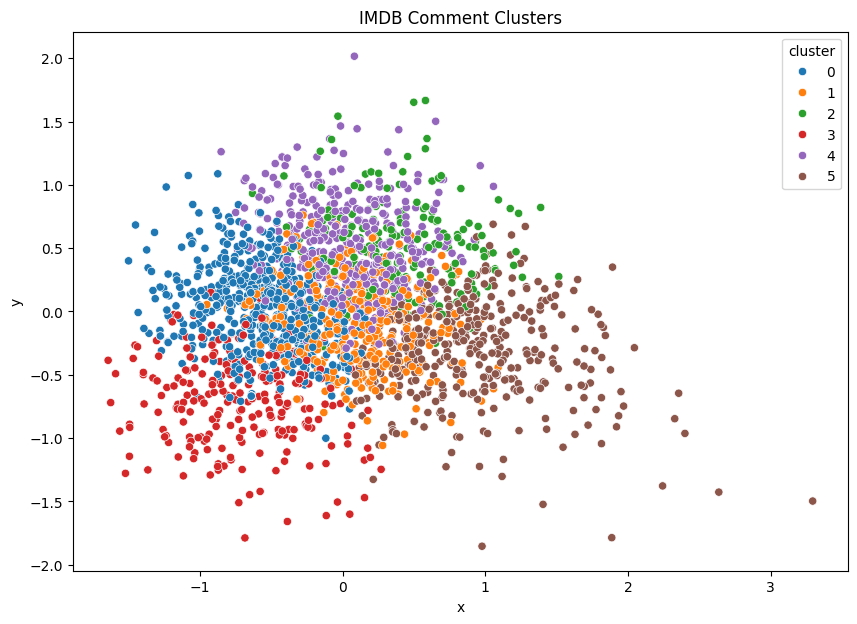

In [22]:
extract_keybert_keywords(df_cn, model, num_keywords=10)

# Run comprehensive analysis
analyze_clusters_comprehensive(df_cn, text_column='clean_comment')

# Extract unique n-grams
extract_unique_ngrams(df_cn, text_column='clean_comment')

# Analyze themes
analyze_cluster_themes(df_cn, text_column='clean_comment')

extract_all_keywords(df_cn, num_clusters, model)

#get random reviews
get_sample_reviews(df_cn, n_samples=3)

# If you have embeddings available
# visualize_clusters(df_cn, embeddings)
visualize_clusters2(df_cn, embeddings)

In [23]:
def print_cluster_table(df):
    # Build the pivot table
    table = df[['title', 'cluster']].value_counts().unstack(fill_value=0)
  
    # Convert floats to ints if needed
    table = table.astype(int)

    # Print each row cleanly
    print("Title".ljust(40), end="")
    for col in table.columns:
        print(f"Cluster {col}".rjust(12), end="")
    print()

    print("-" * (40 + 12 * len(table.columns)))
    
    for title, row in table.iterrows():
        print(title.ljust(40), end="")
        for count in row:
            print(str(count).rjust(12), end="")
        print()

In [24]:
print_cluster_table(df_cn)

Title                                      Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4   Cluster 5
----------------------------------------------------------------------------------------------------------------
12 Angry Men                                       0           3           2           0           2           1
2001: A Space Odyssey                             35           5           1           4          16           1
A Beautiful Mind                                   2           0           6           2           3           4
Avatar                                            33           3          10           9           7           8
Black Swan                                        19           1           0          10          11          10
Bohemian Rhapsody                                  9           3           0           2           5           7
Catch Me If You Can                                0           0           1           0        

In [25]:
df_cn

,title,review_text,stars,url,processed_comment,more_processed_comment,clean_comment,cluster,review_length,x,y
0,12 Angry Men,说实话，我看这部电影是带着审视和质疑的目光看的。因为之前美国发生一起好像是黑人运动员杀妻案，...,1,https://movie.douban.com/review/14243854/,说实话 我看这部电影是带着审视和质疑的目光看的 因为之前美国发生一起好像是黑人运动员杀妻案 ...,说实话 这部 电影 带 审视 质疑 目光 之前 美国 发生 一起 好像 黑人 运动员...,说实话 带 审视 质疑 目光 之前 美国 发生 一起 好像 黑人 运动员 杀妻案 已经 找到...,2,199,0.372784,0.310463
1,12 Angry Men,无罪推定造成的冤假错案更多！\n陪审团应有无利害的专业人士组成！而非容易受人蛊惑的群众！戴维...,1,https://movie.douban.com/review/15777642/,无罪推定造成的冤假错案更多 陪审团应有无利害的专业人士组成 而非容易受人蛊惑的群众 戴维斯妖...,无罪 推定 造成 冤假错案 陪审团 应有 利害 专业人士 组成 容易 受人 蛊惑 群...,无罪 推定 造成 冤假错案 陪审团 应有 利害 专业人士 组成 容易 受人 蛊惑 群众 戴维...,1,462,-0.091430,0.228867
2,12 Angry Men,经典，伟大，完美，任何这样的词来形容这部影片都不为过，可当我看完电影，细细回忆，总觉得哪里有...,1,https://movie.douban.com/review/12413207/,经典 伟大 完美 任何这样的词来形容这部影片都不为过 可当我看完电影 细细回忆 总觉得哪里有...,经典 伟大 完美 词来 形容 这部 影片 不为过 可当 完 电影 细细 ...,经典 伟大 完美 词来 形容 不为过 可当 完 细细 回忆 总 不对劲 心中 出现 不解 表...,4,245,0.828764,0.425701
3,12 Angry Men,在铁证面前，因为案件有疑点就判男孩无罪，那只要有律师，只要请的律师足够好，全世界的罪犯十之八...,1,https://movie.douban.com/review/5839383/,在铁证面前 因为案件有疑点就判男孩无罪 那只要有律师 只要请的律师足够好 全世界的罪犯十之八...,铁证 面前 案件 疑点 就判 男孩 无罪 律师 律师 足够 全世界 罪犯 十...,铁证 面前 案件 疑点 就判 男孩 无罪 律师 律师 足够 全世界 罪犯 十之八九 无罪释放...,5,53,1.484327,0.040150
4,12 Angry Men,戴维斯的很多主张几乎全凭臆想，完全脱离实际全靠诡辩，看的我真的pain in the ass...,2,https://movie.douban.com/review/14125176/,戴维斯的很多主张几乎全凭臆想 完全脱离实际全靠诡辩 看的我真的pain in ass 想跳进...,戴维斯 很多 主张 几乎 全 臆想 完全 脱离实际 全靠 诡辩 真的 pain ...,戴维斯 很多 主张 几乎 全 臆想 完全 脱离实际 全靠 诡辩 pain in ass 想 ...,1,186,0.032874,-0.051978
...,...,...,...,...,...,...,...,...,...,...,...
2148,Whiplash,没啥讨论价值，运镜技巧非常好，尤其是安德鲁练鼓练到疯癫、被车撞之后的打鼓的镜头都是看起来有人...,2,https://movie.douban.com/review/16342721/,没啥讨论价值 运镜技巧非常好 尤其是安德鲁练鼓练到疯癫 被车撞之后的打鼓的镜头都是看起来有人...,没 讨论 价值 运镜 技巧 非常 尤其 安德鲁 练鼓练 疯癫 被车撞 之后 打鼓...,没 讨论 价值 运镜 技巧 非常 尤其 安德鲁 练鼓练 疯癫 被车撞 之后 打鼓 镜头 看起...,1,117,-0.300473,-0.319295
2149,Whiplash,其实是两个疯子互相折磨，中式打压教育入侵阿美利卡，说这部是励志片的挺搞笑的。\n觉得老师其实...,2,https://movie.douban.com/review/16194785/,其实是两个疯子互相折磨 中式打压教育入侵阿美利卡 说这部是励志片的挺搞笑的 觉得老师其实是为...,其实 两个 疯子 互相 折磨 中式 打压 教育 入侵 阿美 利卡 这部 励志 片 挺...,其实 两个 疯子 互相 折磨 中式 打压 教育 入侵 阿美 利卡 励志 片 挺 搞笑 老师 ...,1,187,0.689411,-0.166676
2150,Whiplash,前几天有人推荐此片说了句“严师出高徒”，我想应该来膜拜一下。今天憋闷地看完觉得真是难受，甚至...,2,https://movie.douban.com/review/7590338/,前几天有人推荐此片说了句 严师出高徒 我想应该来膜拜一下 今天憋闷地看完觉得真是难受 甚至有...,前 几天 有人 推荐 此片 句 严师 出 高徒 想 应该 膜拜 一下 今天 憋闷...,前 几天 有人 推荐 此片 句 严师 出 高徒 想 应该 膜拜 一下 今天 憋闷 完 真是 ...,0,100,-0.289286,-0.190616
2151,Whiplash,除了原声，就是一部烂片，男主糟糕的演技，牛头不对马嘴的剧情，最后拍不下去了只能来个做作的嘎然...,2,https://movie.douban.com/review/7366740/,除了原声 就是一部烂片 男主糟糕的演技 牛头不对马嘴的剧情 最后拍不下去了只能来个做作的嘎然...,原 声 一部 烂片 男主 糟糕 演技 牛头不对马嘴 剧情 最后 拍 下去 只...,原 声 烂片 男主 糟糕 演技 牛头不对马嘴 剧情 拍 下去 只能 来个 做作 止 最让人 ...,5,56,0.532572,-0.136479
